In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from pgmpy.models.BayesianNetwork import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pgmpy.estimators import PC
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.models import DiscreteBayesianNetwork


In [3]:
users = pd.read_csv('users.dat', sep='::', engine='python', names=['user_id', 'gender', 'age', 'occupation', 'zip_code'], encoding='latin-1')
movies = pd.read_csv('movies.dat', sep='::', engine='python', names=['movie_id', 'title', 'genres'], encoding='latin-1')
ratings = pd.read_csv('ratings.dat', sep='::', engine='python', names=['user_id', 'movie_id', 'rating', 'timestamp'], encoding='latin-1')


In [4]:
users.head()

,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [5]:
unique_occupations = users['occupation'].unique()
print( unique_occupations)

if all((unique_occupations >= 0) & (unique_occupations <= 20)):
    print("true")
else:
    print("false")


[10 16 15  7 20  9  1 12 17  0  3 14  4 11  8 19  2 18  5 13  6]
true


In [6]:
movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
print(users.isnull().sum())
print(movies.isnull().sum())
print(ratings.isnull().sum())


user_id       0
gender        0
age           0
occupation    0
zip_code      0
dtype: int64
movie_id    0
title       0
genres      0
dtype: int64
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64


In [8]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['year'] = pd.to_numeric(movies['year'], errors='coerce')


In [9]:
users = users[['user_id', 'gender', 'age','occupation']]
movies = movies[['movie_id', 'genres', 'year']]
ratings = ratings[['user_id', 'movie_id', 'rating']]

In [10]:
movies.head()

,movie_id,genres,year
0,1,Animation|Children's|Comedy,1995
1,2,Adventure|Children's|Fantasy,1995
2,3,Comedy|Romance,1995
3,4,Comedy|Drama,1995
4,5,Comedy,1995


In [11]:
ratings

,user_id,movie_id,rating
0,1,1193,5
1,1,661,3
2,1,914,3
3,1,3408,4
4,1,2355,5
...,...,...,...
1000204,6040,1091,1
1000205,6040,1094,5
1000206,6040,562,5
1000207,6040,1096,4


In [12]:
print(users.isnull().sum())
print(movies.isnull().sum())
print(ratings.isnull().sum())


user_id       0
gender        0
age           0
occupation    0
dtype: int64
movie_id    0
genres      0
year        0
dtype: int64
user_id     0
movie_id    0
rating      0
dtype: int64


In [13]:

movies = movies.assign(genres=movies['genres'].str.split('|')).explode('genres')

print(movies.head())

   movie_id      genres  year
0         1   Animation  1995
0         1  Children's  1995
0         1      Comedy  1995
1         2   Adventure  1995
1         2  Children's  1995


In [14]:
duplicate_movies = movies[movies.duplicated(subset='movie_id', keep=False)]
print(duplicate_movies)


      movie_id      genres  year
0            1   Animation  1995
0            1  Children's  1995
0            1      Comedy  1995
1            2   Adventure  1995
1            2  Children's  1995
...        ...         ...   ...
3876      3946      Action  2000
3876      3946       Drama  2000
3876      3946    Thriller  2000
3882      3952       Drama  2000
3882      3952    Thriller  2000

[4383 rows x 3 columns]


In [15]:
def discretize_year_numeric(year):
    if year < 1980:
        return 0
    elif year < 1990:
        return 1
    elif year < 2000:
        return 2
    elif year < 2010:
        return 3
    elif year < 2020:
        return 4
    else:
        return 5


movies['year'] = movies['year'].apply(discretize_year_numeric)


In [16]:
movies['year']

0       2
0       2
0       2
1       2
1       2
       ..
3879    3
3880    3
3881    3
3882    3
3882    3
Name: year, Length: 6408, dtype: int64

In [17]:
label_encoder = LabelEncoder()
users['gender'] = label_encoder.fit_transform(users['gender'])
print(users.head())

   user_id  gender  age  occupation
0        1       0    1          10
1        2       1   56          16
2        3       1   25          15
3        4       1   45           7
4        5       1   25          20


In [18]:
one_hot = pd.get_dummies(movies['genres'])

df_encoded = pd.concat([movies[['movie_id', 'year']], one_hot], axis=1)

movies = df_encoded.groupby(['movie_id', 'year']).max().reset_index()

movies.head()

,movie_id,year,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,2,False,False,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,3,2,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
3,4,2,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False
4,5,2,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False


In [19]:
ratings.columns

Index(['user_id', 'movie_id', 'rating'], dtype='object')

In [20]:

user_avg = ratings.groupby('user_id')['rating'].mean().reset_index(name='avg_rating')

user_high_ratio = (ratings['rating'] >= 4).groupby(ratings['user_id']).mean().reset_index(name='high_rating_ratio')

user_std = ratings.groupby('user_id')['rating'].std().reset_index(name='std_rating')


user_min = ratings.groupby('user_id')['rating'].min().reset_index(name='min_rating')
user_max = ratings.groupby('user_id')['rating'].max().reset_index(name='max_rating')

user_stats = user_avg.merge(user_high_ratio, on='user_id') \
                     .merge(user_std, on='user_id') \
                     .merge(user_min, on='user_id') \
                     .merge(user_max, on='user_id')

user_stats['binned_avg_rating'] = pd.cut(user_stats['avg_rating'], bins=[0,1,2,3,4,5], labels=[1,2,3,4,5])
user_stats['binned_high_rating_ratio'] = pd.cut(user_stats['high_rating_ratio'], bins=[0,0.2,0.4,0.6,0.8,1], labels=[1,2,3,4,5], include_lowest=True)
user_stats['binned_std_rating'] = pd.cut(user_stats['std_rating'], bins=[0,0.5,1,1.5,2,5], labels=[1,2,3,4,5])
user_stats['binned_min_rating'] = pd.cut(user_stats['min_rating'], bins=[0,1,2,3,4,5], labels=[1,2,3,4,5])
user_stats['binned_max_rating'] = pd.cut(user_stats['max_rating'], bins=[0,1,2,3,4,5], labels=[1,2,3,4,5])

user_binned = user_stats[['user_id',
                          'binned_avg_rating',
                          'binned_high_rating_ratio',
                          'binned_std_rating',
                          'binned_min_rating',
                          'binned_max_rating']]


ratings = ratings.merge(user_binned, on='user_id', how='left')


In [21]:
ratings

,user_id,movie_id,rating,binned_avg_rating,binned_high_rating_ratio,binned_std_rating,binned_min_rating,binned_max_rating
0,1,1193,5,5,5,2,3,5
1,1,661,3,5,5,2,3,5
2,1,914,3,5,5,2,3,5
3,1,3408,4,5,5,2,3,5
4,1,2355,5,5,5,2,3,5
...,...,...,...,...,...,...,...,...
1000204,6040,1091,1,4,4,3,1,5
1000205,6040,1094,5,4,4,3,1,5
1000206,6040,562,5,4,4,3,1,5
1000207,6040,1096,4,4,4,3,1,5


In [22]:
ratings = ratings.reset_index(drop=True)
users = users.drop_duplicates(subset='user_id').reset_index(drop=True)
movies = movies.drop_duplicates(subset='movie_id').reset_index(drop=True)


full_data = ratings.merge(users, on='user_id', how='left')


full_data = full_data.merge(movies, on='movie_id', how='left')


In [23]:
full_data.columns

Index(['user_id', 'movie_id', 'rating', 'binned_avg_rating',
       'binned_high_rating_ratio', 'binned_std_rating', 'binned_min_rating',
       'binned_max_rating', 'gender', 'age', 'occupation', 'year', 'Action',
       'Adventure', 'Animation', 'Children's', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
       'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'],
      dtype='object')

In [24]:
full_data['high_rating'] = full_data['rating'].apply(lambda x: 1 if x >= 4 else 0)


In [25]:
train_data, test_data = train_test_split(full_data, test_size=0.2, random_state=42)

In [26]:
train_data["year"]

416292    0
683230    2
2434      2
688533    1
472584    2
         ..
259178    0
365838    2
131932    1
671155    1
121958    2
Name: year, Length: 800167, dtype: int64

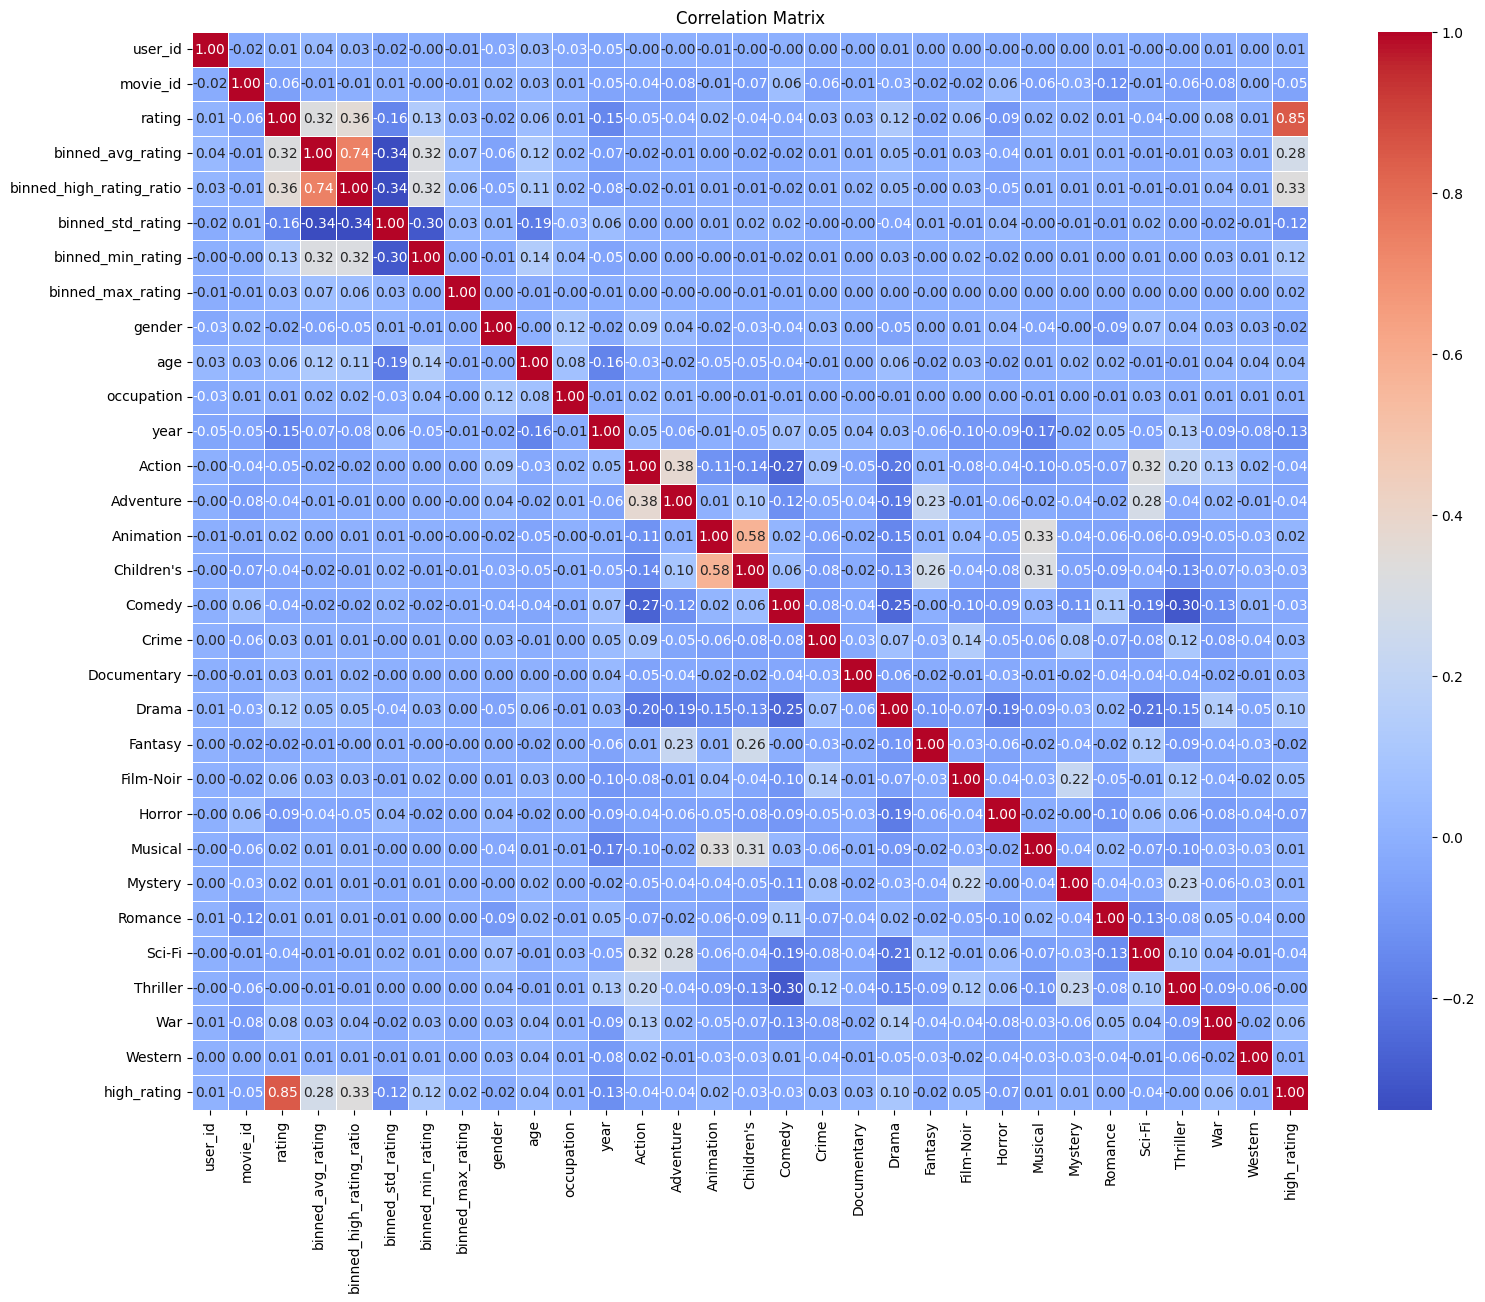

In [27]:
coor_matrix = train_data.corr()
plt.figure(figsize=(18, 14))
sns.heatmap(coor_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [28]:
train_data.columns

Index(['user_id', 'movie_id', 'rating', 'binned_avg_rating',
       'binned_high_rating_ratio', 'binned_std_rating', 'binned_min_rating',
       'binned_max_rating', 'gender', 'age', 'occupation', 'year', 'Action',
       'Adventure', 'Animation', 'Children's', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
       'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western',
       'high_rating'],
      dtype='object')

In [29]:
train_data_encoded = train_data.copy()

for col in train_data_encoded.columns:
    if train_data_encoded[col].dtype in ['bool', 'category']:
        train_data_encoded[col] = train_data_encoded[col].astype(int)


In [30]:
train_data_encoded["year"]

416292    0
683230    2
2434      2
688533    1
472584    2
         ..
259178    0
365838    2
131932    1
671155    1
121958    2
Name: year, Length: 800167, dtype: int64

In [31]:

# est = PC(data=train_data_encoded)

# model = est.estimate(ci_test='g_sq')

# model.fit(train_data_encoded, estimator=MaximumLikelihoodEstimator)

# print("✅ Bayesian network trained successfully using G-Squared CI test.")


In [32]:
train_data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800167 entries, 416292 to 121958
Data columns (total 31 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   user_id                   800167 non-null  int64
 1   movie_id                  800167 non-null  int64
 2   rating                    800167 non-null  int64
 3   binned_avg_rating         800167 non-null  int32
 4   binned_high_rating_ratio  800167 non-null  int32
 5   binned_std_rating         800167 non-null  int32
 6   binned_min_rating         800167 non-null  int32
 7   binned_max_rating         800167 non-null  int32
 8   gender                    800167 non-null  int32
 9   age                       800167 non-null  int64
 10  occupation                800167 non-null  int64
 11  year                      800167 non-null  int64
 12  Action                    800167 non-null  int32
 13  Adventure                 800167 non-null  int32
 14  Animation           

In [33]:
train_data_encoded= train_data_encoded[:9000]

In [34]:
train_data_encoded

,user_id,movie_id,rating,binned_avg_rating,binned_high_rating_ratio,binned_std_rating,binned_min_rating,binned_max_rating,gender,age,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,high_rating
416292,2507,3035,2,4,4,3,1,5,1,25,...,0,0,0,0,0,0,0,1,0,0
683230,4087,2840,4,3,2,3,1,5,1,1,...,0,0,0,0,0,0,1,0,0,1
2434,19,457,3,4,3,3,1,5,1,1,...,0,0,0,0,0,0,1,0,0,0
688533,4118,2804,4,5,4,2,1,5,1,25,...,0,0,0,0,0,0,0,0,0,1
472584,2907,805,4,4,2,3,1,5,0,35,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343697,2018,111,5,4,4,2,1,5,1,35,...,0,0,0,0,0,0,1,0,0,1
584238,3565,2530,3,4,2,3,1,5,1,25,...,0,0,0,0,0,1,0,0,0,0
53429,352,2231,5,4,3,3,1,5,1,18,...,0,0,0,0,0,0,0,0,0,1
973055,5866,678,3,4,4,3,2,5,0,25,...,0,0,0,0,0,0,1,0,0,0


In [ ]:


 edges = [
    ('age', 'high_rating'),
    ('gender', 'high_rating'),
    ('occupation', 'high_rating'),

    ('binned_max_rating','high_rating'),
    ('binned_min_rating','high_rating'),
    ('year', 'high_rating'),

    ('binned_std_rating','high_rating'),
    ('binned_avg_rating', 'high_rating'),
    ('binned_high_rating_ratio', 'high_rating'),

    ('Action','high_rating'),
    ('Drama','high_rating'),
    ('Comedy','high_rating'),
    ('War','high_rating'),
    ('Horror','high_rating'),
    ('Drama','high_rating'),
    ('Film-Noir','high_rating'),


 
]




model = DiscreteBayesianNetwork (edges)
model.fit(train_data_encoded, estimator=MaximumLikelihoodEstimator)



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'user_id': 'N', 'movie_id': 'N', 'rating': 'N', 'binned_avg_rating': 'N', 'binned_high_rating_ratio': 'N', 'binned_std_rating': 'N', 'binned_min_rating': 'N', 'binned_max_rating': 'N', 'gender': 'N', 'age': 'N', 'occupation': 'N', 'year': 'N', 'Action': 'N', 'Adventure': 'N', 'Animation': 'N', "Children's": 'N', 'Comedy': 'N', 'Crime': 'N', 'Documentary': 'N', 'Drama': 'N', 'Fantasy': 'N', 'Film-Noir': 'N', 'Horror': 'N', 'Musical': 'N', 'Mystery': 'N', 'Romance': 'N', 'Sci-Fi': 'N', 'Thriller': 'N', 'War': 'N', 'Western': 'N', 'high_rating': 'N'}


In [36]:
test_data.iloc[0]

user_id                      5412
movie_id                     2683
rating                          2
binned_avg_rating               4
binned_high_rating_ratio        4
binned_std_rating               3
binned_min_rating               1
binned_max_rating               5
gender                          1
age                            25
occupation                     12
year                            2
Action                      False
Adventure                   False
Animation                   False
Children's                  False
Comedy                       True
Crime                       False
Documentary                 False
Drama                       False
Fantasy                     False
Film-Noir                   False
Horror                      False
Musical                     False
Mystery                     False
Romance                     False
Sci-Fi                      False
Thriller                    False
War                         False
Western       

In [37]:


# infer = VariableElimination(model)

# test_sample = {
#     'age': 18,
#     'gender': 0,
#     'occupation':4,
#     'Action': 0,
#     'Drama': 0,
#     'Comedy': 0,
#     'Thriller': 0,
#     'Western':0,
#     'Sci-Fi' : 0,
#     'Film-Noir': 0,
#     'binned_avg_rating':'High',
#     'binned_high_rating_ratio':'Medium',
#     'Documentary':0,
#     'Crime':0,
#     "Children's":0,
#     'Animation':0,
#     'Romance':1,

# }

# prediction = infer.query(variables=['high_rating'], evidence=test_sample)

# print(prediction)

In [38]:
test_data.columns

Index(['user_id', 'movie_id', 'rating', 'binned_avg_rating',
       'binned_high_rating_ratio', 'binned_std_rating', 'binned_min_rating',
       'binned_max_rating', 'gender', 'age', 'occupation', 'year', 'Action',
       'Adventure', 'Animation', 'Children's', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
       'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western',
       'high_rating'],
      dtype='object')

In [ ]:
X_test = test_data.drop(columns=['high_rating',"user_id",'movie_id','rating', 'Adventure', 'Animation',
       "Children's", 'Crime', 'Documentary', 'Fantasy',
         'Musical', 'Mystery', 'Romance', 'Sci-Fi',
       'Thriller', 'Western', 'high_rating'])
X_test=X_test[:500]


In [60]:
X_test

,binned_avg_rating,binned_high_rating_ratio,binned_std_rating,binned_min_rating,binned_max_rating,gender,age,occupation,year,Action,Comedy,Drama,Horror,War
895536,4,4,3,1,5,1,25,12,2,False,True,False,False,False
899739,5,4,2,2,5,0,45,2,0,False,False,False,False,False
55687,4,4,2,1,5,1,25,0,3,True,False,False,False,False
63727,4,4,2,1,5,1,25,12,2,False,False,True,False,False
822011,4,3,2,1,5,1,45,12,2,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383126,4,4,3,1,5,0,25,4,2,False,False,True,False,False
416912,4,4,3,1,5,1,25,4,2,False,True,False,False,False
62819,4,4,2,1,5,1,25,17,1,True,False,False,False,False
208845,4,4,2,2,5,1,45,7,0,False,True,True,False,False


In [61]:
from pgmpy.inference import VariableElimination
infer = VariableElimination(model)


In [62]:

predictions = []

for idx, row in X_test.iterrows():   
    evidence = row.to_dict()
    prediction = infer.query(variables=['high_rating'], evidence=evidence)
    
    prob_high_rating = prediction.values[1]  
    
    pred_label = 1 if prob_high_rating > 0.5 else 0
    predictions.append(pred_label)

X_test['predicted_high_rating'] = predictions

print(X_test[['predicted_high_rating']])


        predicted_high_rating
895536                      0
899739                      0
55687                       0
63727                       1
822011                      0
...                       ...
383126                      0
416912                      1
62819                       0
208845                      0
875599                      0

[500 rows x 1 columns]


In [63]:
X_test['predicted_high_rating'].shape

(500,)

In [64]:
correct_predictions = (X_test['predicted_high_rating'] == test_data['high_rating'][:500]).sum()
total_predictions = len(X_test)

accuracy = correct_predictions / total_predictions

print(f" {correct_predictions}")
print(f" {total_predictions}")
print(f" {accuracy:.2f}")

 231
 500
 0.46
